<a href="https://colab.research.google.com/github/ELEAZAR22-ai/PUIS23210001/blob/main/Copy_of_ML_project_simple_linear_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Fundamentals of Machine Learning

Machine Learning (ML) is a subfield of Artificial Intelligence that focuses on building systems that learn from data, identify patterns, and make decisions with minimal human intervention.

### Types of Machine Learning

1. **Supervised Learning**: The model is trained on a labeled dataset. The goal is to learn a mapping from inputs to outputs.
    *   *Examples*: Predicting house prices (Regression), spam detection (Classification).
2. **Unsupervised Learning**: The model finds hidden patterns in unlabeled data.
    *   *Examples*: Customer segmentation (Clustering).
3. **Reinforcement Learning**: An agent learns by trial and error to maximize rewards.

---

## Our Toolkit: The Libraries

To build our model, we use several powerful Python libraries. Here is what they do and why they are in our pipeline:

*   **`pandas`**: The 'Excel of Python'. We use it for **Step 1 (Loading)** and **Step 2 (Cleaning)** to handle data tables (DataFrames).
*   **`matplotlib` & `seaborn`**: Our visualization tools. Crucial for **Step 3 (EDA)** to see patterns in the data.
*   **`scikit-learn` (sklearn)**: The primary ML library. It provides tools for **Step 4 (Splitting)**, **Step 5 & 6 (Building/Fitting)**, and **Step 7 (Evaluation)**.
*   **`joblib`**: Used for **Step 8 (Saving)** to export our trained model to a file.

# Machine Learning Project: Simple Linear Regression

Welcome to your first practical machine learning project! In this notebook, we will explore the fundamentals of supervised learning by building a model that predicts a continuous value based on a single input feature.

### The Pipeline:
1. Data Loading
2. Data Cleaning
3. Exploratory Data Analysis (EDA)
4. Splitting Data
5. Building the Model
6. Fitting the Model
7. Evaluation
8. Saving the Model

In [ ]:
# 0. Notebook Setup: Consolidated Imports

# Pandas is used for data manipulation and analysis
import pandas as pd
# io is used for handling Python's main facilities for dealing with various types of I/O
import io
# Matplotlib and Seaborn are used for data visualization (graphs and charts)
import matplotlib.pyplot as plt
import seaborn as sns
# Joblib is used to save and load Python objects (like our ML model)
import joblib
# Files and Drive allow us to interact with the Colab environment and Google Drive
from google.colab import files, drive
# Sklearn provides the machine learning algorithms and utility functions
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn import metrics
#from sklearn.metrics import mean_squared_error, r2_score

print("Libraries imported successfully. We are ready to begin the pipeline!")

## Preparing for the Project

Now that we understand the theory and our toolkit, let's prepare to use our own data.

### About Your Dataset
In this project, we are performing **Simple Linear Regression**. This means you will pick one feature (your independent variable) to see how well it predicts a target value (your dependent variable).

## 1. Data Loading
In Google Colab, there are two common ways to handle data: loading it directly for a single session, or mounting Google Drive for persistent access.

In [ ]:
# 1. Data Loading

# 'files.upload()' triggers a browser window to select a file from your local machine.
print("Please upload your CSV file:")
uploaded = files.upload()

# 'uploaded' is a dictionary where keys are filenames. We extract the first key to get the name.
file_name = list(uploaded.keys())[0]

# 'pd.read_csv' creates a DataFrame. 'io.BytesIO' converts the raw binary upload into a format pandas can read.
df = pd.read_csv(io.BytesIO(uploaded[file_name]))

# Option B: Persistent Storage (Google Drive)
# 'drive.mount' links your Google Drive to this Colab session.
# drive.mount('/content/drive')
# 'pd.read_csv' would then point to a specific file path within your Drive folders.
# df = pd.read_csv('/content/drive/MyDrive/path_to_your_data/age_weight.csv')

print(f"Dataset '{file_name}' loaded successfully!")
# 'display(df.head())' shows the first 5 rows to verify the data structure.
display(df.tail())

Please upload your CSV file:


Saving age_weight_synthetic_dataset_100.csv to age_weight_synthetic_dataset_100 (4).csv
Dataset 'age_weight_synthetic_dataset_100 (4).csv' loaded successfully!


,Age_Independent_variable,Weight_kg_dependent_variable
95,26,57.9
96,59,77.4
97,48,73.4
98,59,81.9
99,47,62.8


## 2. Data Cleaning
We check for missing values and ensure data types are correct.

In [ ]:
# 2. Data Cleaning

# 'df.isnull().sum()' counts how many empty (NaN) values exist in every column.
print("Missing values:")
print(df.isnull().sum())

# 'df.dtypes' tells us if columns are numbers (int/float) or text (object).
# ML models require numerical data to perform calculations.
print("\nData Types:")
print(df.dtypes)

Missing values:
Age_Independent_variable        0
Weight_kg_dependent_variable    0
dtype: int64

Data Types:
Age_Independent_variable          int64
Weight_kg_dependent_variable    float64
dtype: object


## 3. Basic Exploratory Data Analysis (EDA)
Visualizing the relationship between variables.

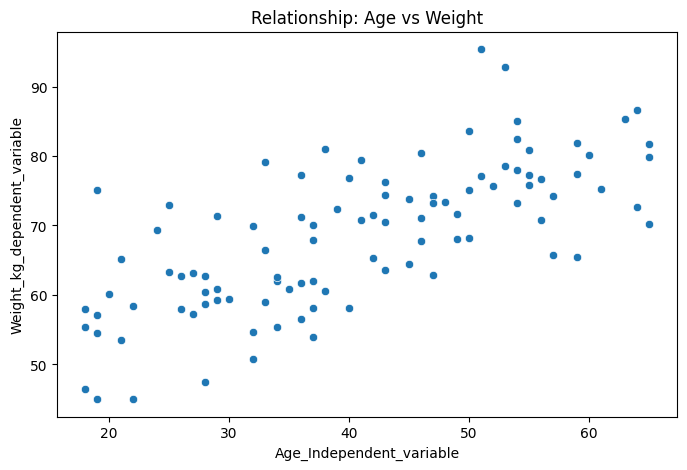

In [ ]:
# 3. Basic Exploratory Data Analysis (EDA)

# 'plt.figure' sets the dimensions of our plot in inches (width, height).
plt.figure(figsize=(8, 5))

# 'sns.scatterplot' creates a dot plot to visualize the correlation between variables.
# 'x' is our cause (Age), 'y' is our effect/target (Weight).
sns.scatterplot(x='Age_Independent_variable', y='Weight_kg_dependent_variable', data=df)

# 'plt.title' adds a descriptive heading to the chart.
plt.title('Relationship: Age vs Weight')

# 'plt.show()' renders the final image in the notebook.
plt.show()

## 4. Splitting the Data
Separating the data into training and testing sets.

In [ ]:
# 4. Splitting the Data into Train, Validation, and Test

# X (Input) and y (Target)
X = df[['Age_Independent_variable']]
y = df['Weight_kg_dependent_variable']

# First, we split into 'Train' and a temporary 'Remnant' (40% for validation + test)
# This leaves 60% for training
X_train, X_rem, y_train, y_rem = train_test_split(X, y, test_size=0.4, random_state=42)

# Now, we split the 'Remnant' equally into Validation and Test (20% each of the total)
X_val, X_test, y_val, y_test = train_test_split(X_rem, y_rem, test_size=0.5, random_state=42)

print(f"Data split successfully:")
print(f"- Training: {len(X_train)} samples")
print(f"- Validation: {len(X_val)} samples")
print(f"- Testing: {len(X_test)} samples")

Data split successfully:
- Training: 60 samples
- Validation: 20 samples
- Testing: 20 samples


### Data Split Verification
It is good practice to inspect our training and testing sets to ensure the split occurred as expected. This helps us confirm that the shapes match and the data looks correct before feeding it into the algorithm.

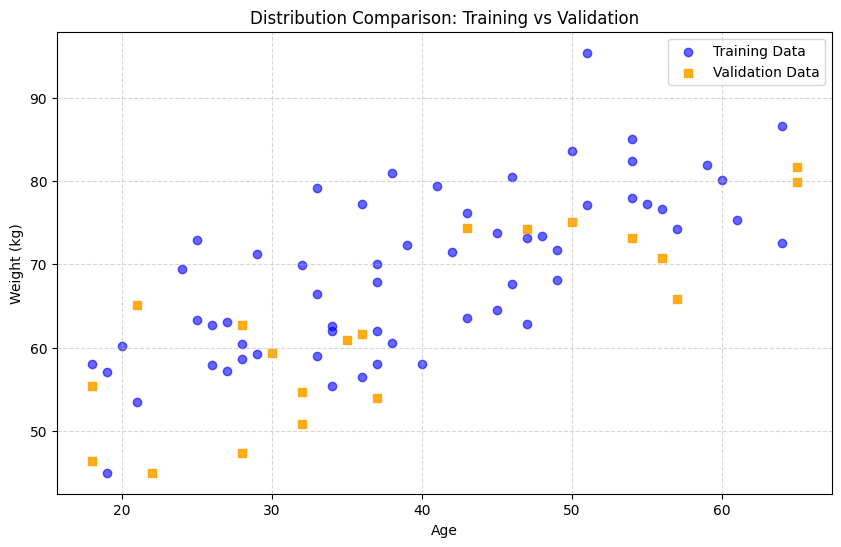

,Dataset Part,Count,Purpose
0,X_train,60,Model learning
1,X_val,20,Hyperparameter tuning/Intermediate check
2,X_test,20,Final performance check


In [ ]:
# Visualizing Train vs Validation Data
plt.figure(figsize=(10, 6))

# Plot Training data in blue
plt.scatter(X_train, y_train, color='blue', label='Training Data', alpha=0.6)

# Plot Validation data in orange
plt.scatter(X_val, y_val, color='orange', label='Validation Data', alpha=0.9, marker='s')

plt.title('Distribution Comparison: Training vs Validation')
plt.xlabel('Age')
plt.ylabel('Weight (kg)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# Updated Summary Table
split_summary = pd.DataFrame({
    'Dataset Part': ['X_train', 'X_val', 'X_test'],
    'Count': [len(X_train), len(X_val), len(X_test)],
    'Purpose': ['Model learning', 'Hyperparameter tuning/Intermediate check', 'Final performance check']
})
display(split_summary)

## 5. Building and 6. Fitting the Model
Creating the Linear Regression object and training it.

In [ ]:
# 5. Building the Model
# 'LinearRegression()' initializes the mathematical algorithm.
model = LinearRegression()

# 6. Fitting the Model
# '.fit()' is the 'learning' step where the model calculates the best slope (m) and intercept (b).
# It uses the training data (X_train, y_train) to find patterns.
model.fit(X_train, y_train)

print("Model training complete.")

NameError: name 'LinearRegression' is not defined

## 7. Running Evaluation Metrics
Evaluating how well our model performs.

### Visual Comparison: Actual vs. Predicted
Before we look at the mathematical averages (metrics), let's look at specific examples of how our model's 'guesses' compare to the real data.

In [ ]:
# 7a. Visual Comparison (Validation Set)
# We generate predictions for the Validation set (X_val) to check intermediate performance
y_val_pred = model.predict(X_val)

# Create the base comparison DataFrame
comparison_df = pd.DataFrame({
    'Actual Weight (kg)': y_val.values,
    'Predicted Weight (kg)': y_val_pred.flatten()
}).head(10)

# Calculate Residuals (Actual - Predicted)
comparison_df['Residual'] = comparison_df['Actual Weight (kg)'] - comparison_df['Predicted Weight (kg)']

# Add Interpretation column
def interpret_residual(res):
    if res > 1: # Allowance for small differences
        return "Underestimated"
    elif res < -1:
        return "Overestimated"
    else:
        return "Close Prediction"

comparison_df['Interpretation'] = comparison_df['Residual'].apply(interpret_residual)

# Formatting the display for better readability
print("First 10 Validation Samples: Formatted Comparison Table")

def highlight_diff(val):
    if val == 'Underestimated': color = 'orange'
    elif val == 'Overestimated': color = 'lightblue'
    else: color = 'lightgreen'
    return f'background-color: {color}'

# Using .map instead of .applymap to avoid deprecation warnings
display(comparison_df.style.format({
    'Predicted Weight (kg)': '{:.2f}',
    'Residual': '{:.2f}'
}).map(highlight_diff, subset=['Interpretation']))

First 10 Validation Samples: Formatted Comparison Table


/tmp/ipykernel_1130/2713377006.py:38: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  }).applymap(highlight_diff, subset=['Interpretation']))


,Actual Weight (kg),Predicted Weight (kg),Residual,Interpretation
0,62.700000,62.37,0.33,Close Prediction
1,79.900000,83.45,-3.55,Overestimated
2,46.400000,56.68,-10.28,Overestimated
3,81.700000,83.45,-1.75,Overestimated
4,50.800000,64.65,-13.85,Overestimated
5,75.100000,74.90,0.20,Close Prediction
6,59.400000,63.51,-4.11,Overestimated
7,55.400000,56.68,-1.28,Overestimated
8,65.100000,58.38,6.72,Underestimated
9,74.200000,73.19,1.01,Underestimated


In [ ]:
# 7b. Running the Evaluation Metrics (Validation Set)

# Using validation predictions to calculate scores
print('--- Validation Metrics ---')
print('Mean Absolute Error:', metrics.mean_absolute_error(y_val, y_val_pred))
print('Mean Squared Error:', metrics.mean_squared_error(y_val, y_val_pred))
print('R-squared Score:', metrics.r2_score(y_val, y_val_pred))

--- Validation Metrics ---
Mean Absolute Error: 6.709347793899911
Mean Squared Error: 69.5439997699956
R-squared Score: 0.4282571414830457


### 7c. Final Evaluation (Test Set)
Now that we are satisfied with our model's performance on the validation data, we perform one final check using the **Test Set**. This represents the model's performance on completely unseen data.

In [ ]:
# Generate predictions for the final Test Set
y_test_pred = model.predict(X_test)

# Calculate final metrics
test_mae = metrics.mean_absolute_error(y_test, y_test_pred)
test_mse = metrics.mean_squared_error(y_test, y_test_pred)
test_r2 = metrics.r2_score(y_test, y_test_pred)

print('--- Final Test Metrics ---')
print(f'Mean Absolute Error: {test_mae}')
print(f'Mean Squared Error: {test_mse}')
print(f'R-squared Score: {test_r2}')

print('\n--- Comparison with Validation ---')
# This helps students see if the model's performance is consistent
print(f'Validation R2: {metrics.r2_score(y_val, y_val_pred):.4f}')
print(f'Test R2: {test_r2:.4f}')

--- Final Test Metrics ---
Mean Absolute Error: 5.3493489043529765
Mean Squared Error: 58.253085905538526
R-squared Score: 0.2483133314983449

--- Comparison with Validation ---
Validation R2: 0.4283
Test R2: 0.2483


## 8. Saving the Model
Exporting the model for future use.

In [ ]:
# 8. Saving the Model

# 'joblib.dump' takes the trained 'model' object and saves it as a binary file.
# This allows you to use the model later without retraining it.
import joblib
joblib.dump(model, 'simple_linear_model.pkl')

print("Model saved successfully as simple_linear_model.pkl")

Model saved successfully as simple_linear_model.pkl


## 9. Making Predictions with the Saved Model
One of the most important steps in Machine Learning is using your trained model in a real-world application. Once saved, you can load the model into a different script or application to make predictions on new data.

In [ ]:
# Load the saved model
loaded_model = joblib.load('simple_linear_model.pkl')

# Define a new 'Age' to predict weight for
# Best Practice: Use a DataFrame with the same column name used during training
new_data = pd.DataFrame({'Age_Independent_variable': [35]})

# Make a prediction
predicted_weight = loaded_model.predict(new_data)

print(f"--- Real-World Prediction ---")
print(f"For an Age of {new_data.iloc[0,0]}, the predicted Weight is: {predicted_weight[0]:.2f} kg")

--- Real-World Prediction ---
For an Age of 35, the predicted Weight is: 66.36 kg


## Summary and Next Steps
Congratulations! You've built a Simple Linear Regression model. You can now experiment by choosing different features (like `total_rooms`) to see how they predict house values.

### Summary of What We Learned:
1. **Data Prep**: How to load and clean data using `pandas`.
2. **EDA**: Visualizing relationships between variables.
3. **Best Practices**: Splitting data into Training, Validation, and Testing sets.
4. **Linear Regression**: Training a model to find the line of best fit.
5. **Evaluation**: Using metrics like MAE and R-squared to judge performance.
6. **Persistence**: Saving and reloading your model for future use.

In [ ]:
---
**Note to Student:** Always ensure you have run the 'Notebook Setup' cell at the top before proceeding with the pipeline steps below.

# End of Tutorial